# IMPORT

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

path = r'D:\pandas\source files\project'

# rides.csv

In [2]:
df_r = pd.read_csv(path + r'\rides.csv', sep=',', encoding='UTF-8')

## Предобработка данных

### PEP-8 и типы данных

In [3]:
df_r.columns = df_r.columns.str.lower().str.replace(' ', '_')
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              102255 non-null  int64  
 1   start_date      102255 non-null  object 
 2   end_date        102255 non-null  object 
 3   start_location  102255 non-null  object 
 4   start_district  102255 non-null  object 
 5   end_location    102255 non-null  object 
 6   end_district    102255 non-null  object 
 7   distance        101022 non-null  float64
 8   promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


In [12]:
df_r['start_date'] = pd.to_datetime(df_r['start_date'])
df_r['end_date'] = pd.to_datetime(df_r['end_date'])

### Дубликаты

#### Явные дубликаты

In [6]:
df_r.duplicated().sum()

np.int64(4883)

In [7]:
df_r.duplicated().mean()

np.float64(0.047753166104346975)

In [8]:
dups = df_r[df_r.duplicated(keep=False)]

In [9]:
dups.sort_values('id')

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
16,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
17,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
45,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
44,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
81,100419,2023-04-22 11:31:18,2023-04-22 12:03:19,Цветочная,северо-западный,Коммунальная,Юго-Восточный,4801.0,0
...,...,...,...,...,...,...,...,...,...
102181,197640,2023-07-31 21:43:19,2023-07-31 21:58:08,Кирова,Ленинский,Коммунальная,Юго-Восточный,2809.0,0
102183,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102184,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102205,197662,2023-07-31 21:57:30,2023-07-31 22:26:37,Дорожная,Юго-Восточный,Сиреневая,Юго-Восточный,3700.0,0


In [10]:
df_r[df_r.duplicated(keep=False)].shape

(9766, 9)

видим что строки сдвоены, 4883 дубликатов, 9766 наблюдений

In [11]:
df_r.drop_duplicates() # избавились от явных дубликатов, приступим к неявным

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


#### Неявные дубликаты

### Выбросы

In [13]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              102255 non-null  int64         
 1   start_date      102255 non-null  datetime64[ns]
 2   end_date        101676 non-null  datetime64[ns]
 3   start_location  102255 non-null  object        
 4   start_district  102255 non-null  object        
 5   end_location    102255 non-null  object        
 6   end_district    102255 non-null  object        
 7   distance        101022 non-null  float64       
 8   promo           102255 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 7.0+ MB


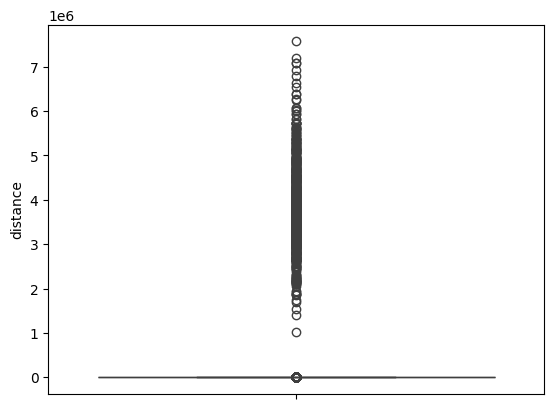

In [15]:
sns.boxplot(df_r, y='distance')
plt.show()

In [18]:
print(df_r['distance'].max())

7569789.0


смею предположить что в исходном файле distance на самом деле в мм. а не в м. Иначе большенство наших клинетов ездило от миллиона метров за поездку

In [20]:
df_r['distance'] = df_r['distance'] / 1000 # перевели в метры distance

In [23]:
max_dist = df_r['distance'].max()
row = df_r.loc[df_r['distance'] == max_dist]
print(row) # смотрим почему проехал больше всех

           id          start_date            end_date start_location  \
78664  175247 2023-07-10 09:57:49 2023-07-10 10:39:40         Лесная   

      start_district   end_location     end_district  distance  promo  
78664  юго-восточный  ул. березовая  Северо-Западный  7.569789      1  
